In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.feature_extraction.text import CountVectorizer

### 1. data quick info

In [2]:

s3_path = "s3://mlops-project-bucket-602343785232-ap-southeast-1-an/raw_data/IT Support Ticket Data.csv"
df = pd.read_csv(s3_path)



In [3]:
df.head()

,Unnamed: 0,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  29651 non-null  int64
 1   Body        29650 non-null  str  
 2   Department  29651 non-null  str  
 3   Priority    29651 non-null  str  
 4   Tags        29651 non-null  str  
dtypes: int64(1), str(4)
memory usage: 14.4 MB


In [5]:
df['Priority'].unique()

<ArrowStringArray>
['high', 'medium', 'low']
Length: 3, dtype: str

In [6]:
df['Department'].unique()

<ArrowStringArray>
[              'Technical Support',           'Returns and Exchanges',
            'Billing and Payments',             'Sales and Pre-Sales',
 'Service Outages and Maintenance',                 'Product Support',
                      'IT Support',                'Customer Service',
                 'Human Resources',                 'General Inquiry']
Length: 10, dtype: str

In [7]:
df['Body'].duplicated().sum()

np.int64(4595)

### 2. drop row with NaN + remove duplicate

In [8]:

# row with null value
df[df['Body'].isnull()]
# id = 28901


,Unnamed: 0,Body,Department,Priority,Tags
28901,28901,NaN,Product Support,high,"['Technical Support', 'Product Support', 'Gene..."


In [9]:
df.dropna(subset=["Body"], inplace=True)
df.drop_duplicates(subset="Body", inplace=True)
df.reset_index(drop=True, inplace=True)


# 3. visualizing catagorical data distribution

#### priority distribution

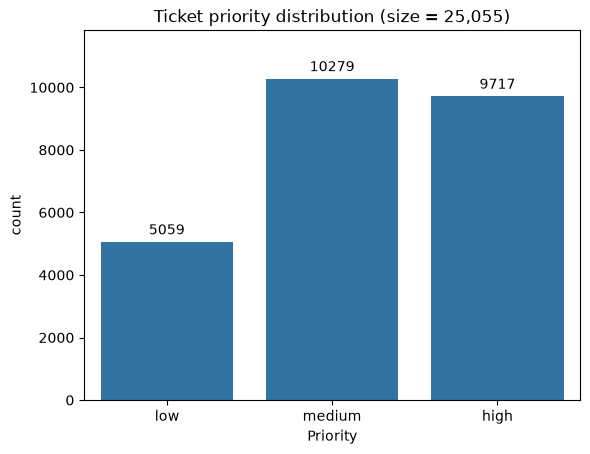

In [10]:
ax = sns.countplot(data=df, x="Priority", order=["low", "medium", "high"])
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
ax.margins(y=0.15)
plt.title(f"Ticket priority distribution (size = {len(df):,})")
plt.show()


#### department distribution

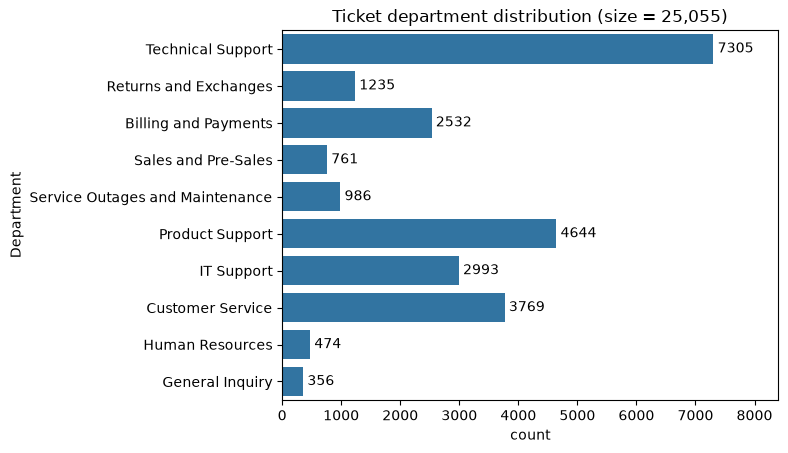

In [11]:
ax = sns.countplot(data=df, y="Department")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
ax.margins(x=0.15)
plt.title(f"Ticket department distribution (size = {len(df):,})")
plt.show()


### 4. visualize text data

In [12]:
df["word_count"] = df["Body"].str.split().str.len()


In [13]:
# visualize tag

In [14]:

tag_df = df["Tags"].apply(ast.literal_eval)

In [15]:
tag_set = set()
row_to_skim = 3000
cnt = 0
for index, list_ in tag_df.items():
    if(cnt == row_to_skim):
        break
    for tag in list_:
        tag_set.add(tag)
    cnt = cnt + 1
print(f"there are {len(tag_set)} unique tags")

there are 599 unique tags


In [16]:
# given that there are almost 599 tag already, after scanning 3000 row, this column "Tags" are not going to be sued

#### 4.1 analysise word frequency unigram, bigram and trigram with or without stopword

In [40]:
priorities = ["low", "medium", "high"]


def get_ngram_counts(corpus, ngram_range, stop_words=None):
    vec = CountVectorizer(stop_words=stop_words, ngram_range=ngram_range)
    bag_of_words = vec.fit_transform(corpus)

    return pd.DataFrame({
        "Word": vec.get_feature_names_out(),
        "Freq": bag_of_words.sum(axis=0).A1
    })


def build_priority_ngrams(ngram_size, stop_words=None):
    result = pd.DataFrame()

    for priority in priorities:
        body = df.loc[df["Priority"] == priority, "Body"]
        counts = get_ngram_counts(body, (ngram_size, ngram_size), stop_words)
        counts = counts.rename(columns={"Freq": f"Freq_{priority}"})

        if result.empty:
            result = counts
        else:
            result = result.merge(counts, on="Word", how="outer")

    freq_cols = [f"Freq_{priority}" for priority in priorities]
    result[freq_cols] = result[freq_cols].fillna(0).astype(int)
    result["Freq_total"] = result[freq_cols].sum(axis=1)
    return result.sort_values("Freq_total", ascending=False).reset_index(drop=True)


In [41]:
unigrams_with_stop = build_priority_ngrams(1)
bigrams_with_stop = build_priority_ngrams(2)
trigrams_with_stop = build_priority_ngrams(3)

unigrams_without_stop = build_priority_ngrams(1, stop_words="english")
bigrams_without_stop = build_priority_ngrams(2, stop_words="english")
trigrams_without_stop = build_priority_ngrams(3, stop_words="english")


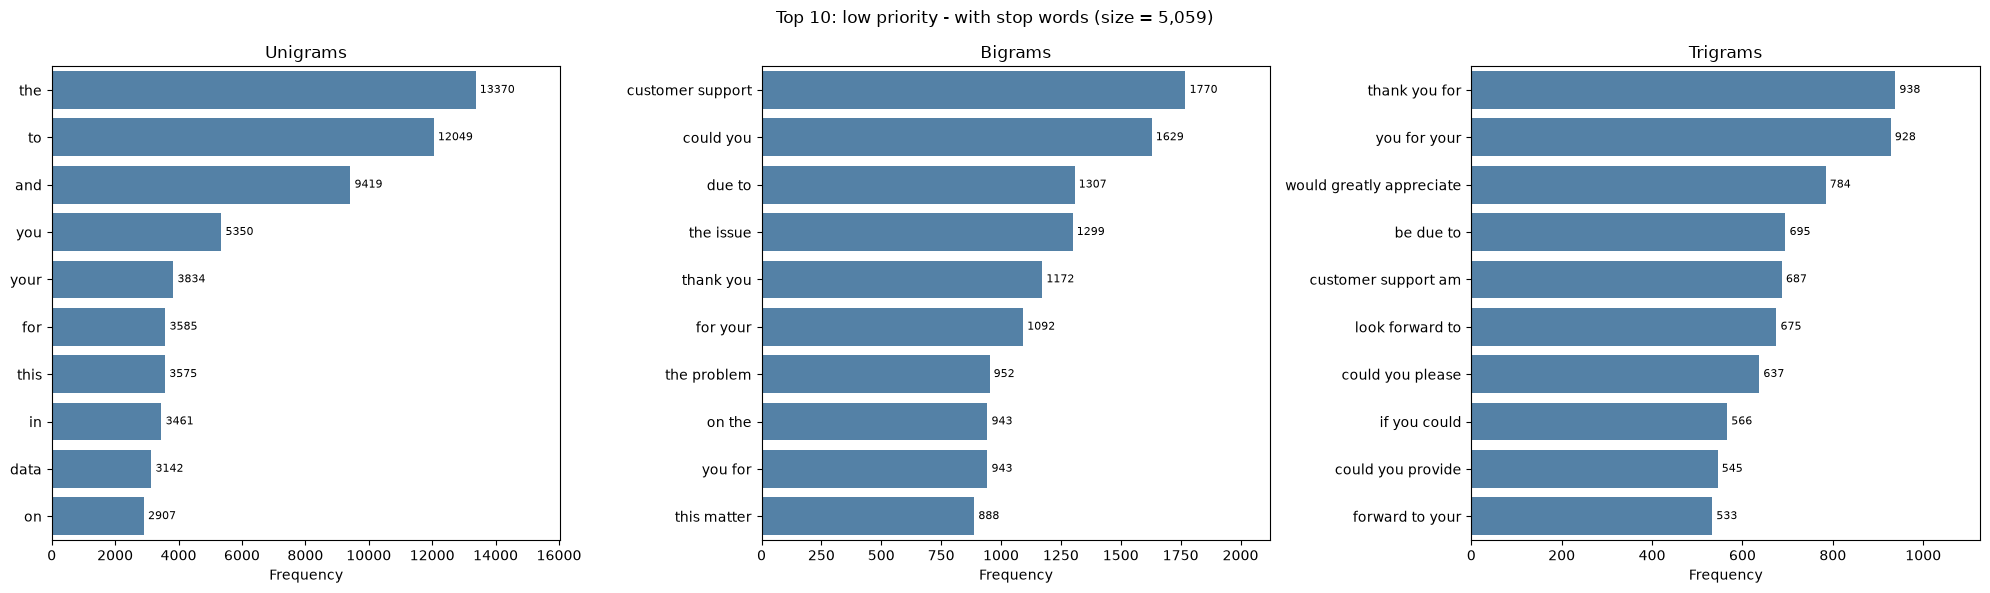

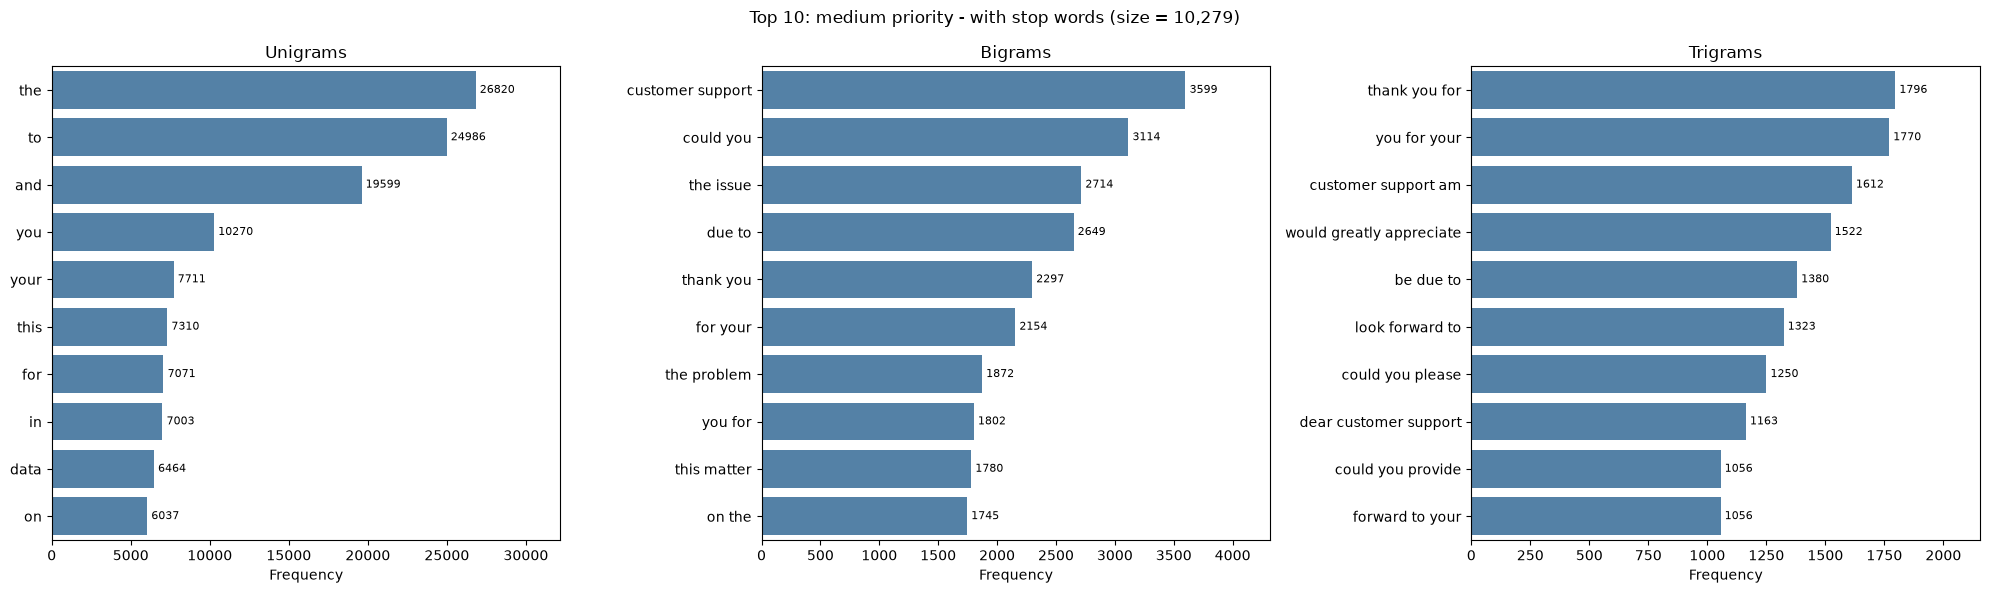

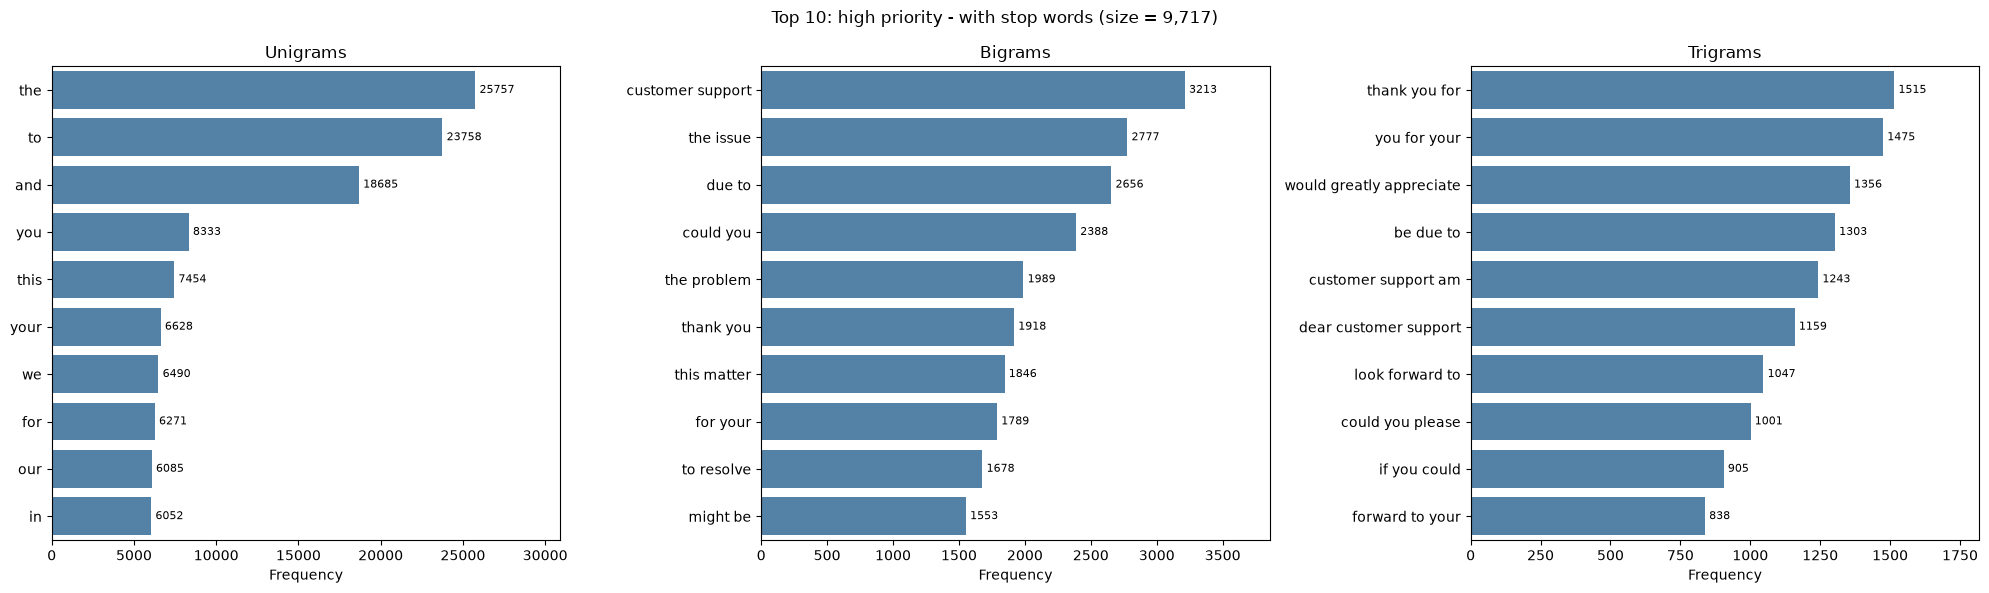

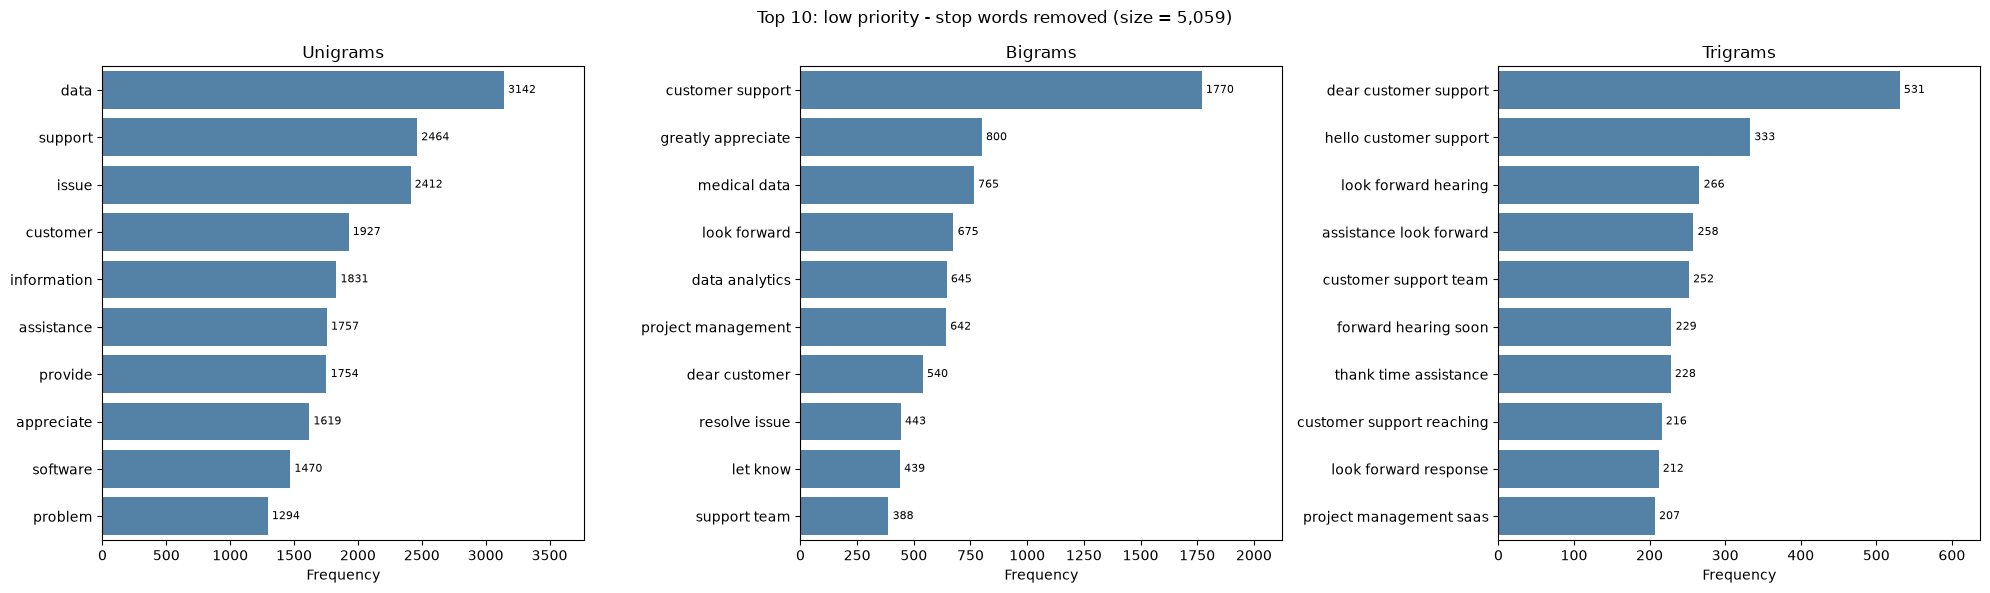

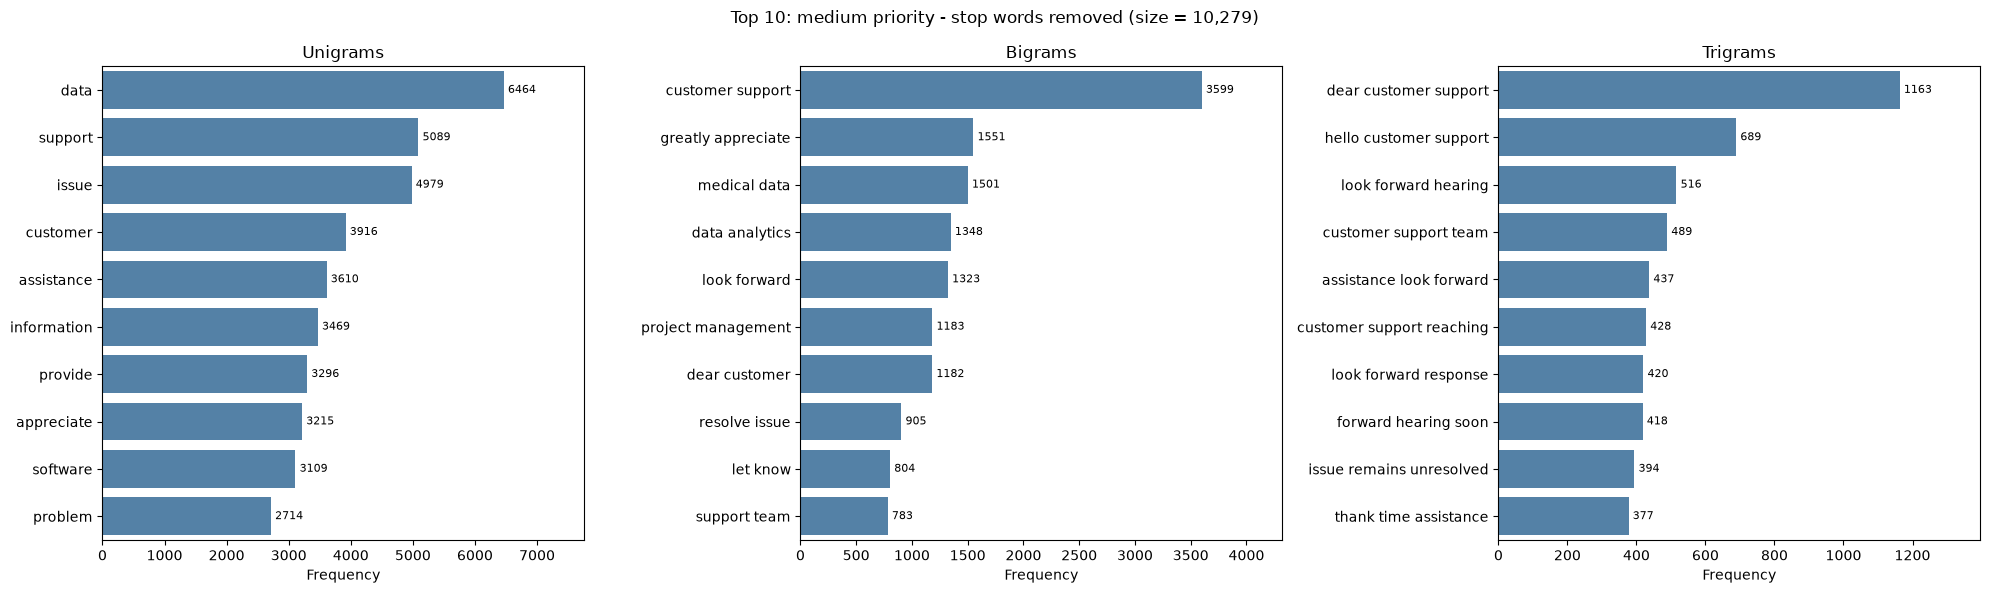

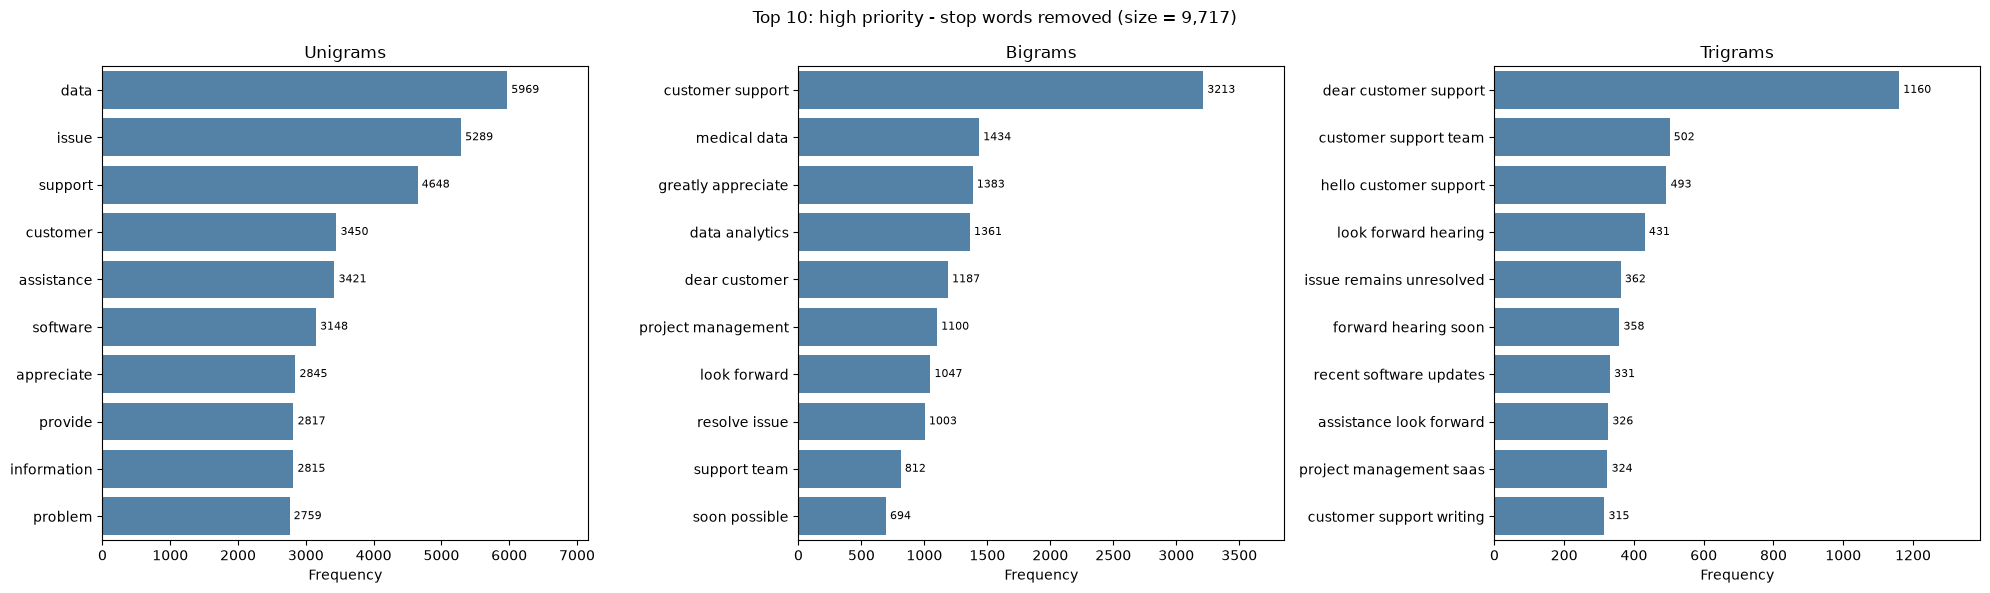

In [44]:
def plot_top_ngrams(priority, unigram_counts, bigram_counts, trigram_counts, title, n=10):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    tables = [unigram_counts, bigram_counts, trigram_counts]
    names = ["Unigrams", "Bigrams", "Trigrams"]
    freq_col = f"Freq_{priority}"

    for ax, table, name in zip(axes, tables, names):
        counts = table.sort_values(freq_col, ascending=False).head(n)
        sns.barplot(data=counts, x=freq_col, y="Word", color="steelblue", ax=ax)
        ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=8)
        ax.set(title=name, xlabel="Frequency", ylabel="")
        ax.margins(x=0.2)

    size = (df["Priority"] == priority).sum()
    fig.suptitle(f"Top {n}: {priority} priority - {title} (size = {size:,})")
    plt.tight_layout()
    plt.show()


# Include stop words
plot_top_ngrams("low", unigrams_with_stop, bigrams_with_stop, trigrams_with_stop, "with stop words")
plot_top_ngrams("medium", unigrams_with_stop, bigrams_with_stop, trigrams_with_stop, "with stop words")
plot_top_ngrams("high", unigrams_with_stop, bigrams_with_stop, trigrams_with_stop, "with stop words")

# Remove English stop words
plot_top_ngrams("low", unigrams_without_stop, bigrams_without_stop, trigrams_without_stop, "stop words removed")
plot_top_ngrams("medium", unigrams_without_stop, bigrams_without_stop, trigrams_without_stop, "stop words removed")
plot_top_ngrams("high", unigrams_without_stop, bigrams_without_stop, trigrams_without_stop, "stop words removed")


#### 4.2 top n most frequenct unigram, bigram and trigram with or without stop word that appear solely on a distinctive priority

In [50]:
def distinctive_score(counts):
    result = counts[["Word"]].copy()

    for priority in priorities:
        other_cols = [f"Freq_{p}" for p in priorities if p != priority]
        result[f"score_distinctive_{priority}"] = counts[f"Freq_{priority}"] / (counts[other_cols].sum(axis=1) + 1)

    return result


def top_distinctive(scores, counts, ngram_name, n=10, min_freq=5):
    rows = []
    for priority in priorities:
        score_col = f"score_distinctive_{priority}"
        freq_col = f"Freq_{priority}"
        result = counts[["Word", freq_col]].merge(scores[["Word", score_col]], on="Word")
        result = result[result[freq_col] >= min_freq]
        result = result.rename(columns={freq_col: "Freq_this", score_col: "score"})
        result["Priority"] = priority
        result["Ngram"] = ngram_name
        rows.append(result.sort_values("score", ascending=False).head(n))

    return pd.concat(rows, ignore_index=True)


def plot_distinctive(priority, distinctive_counts, with_stopword=False):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    compared_with = " + ".join([p for p in priorities if p != priority])

    for ax, name in zip(axes, ["Unigrams", "Bigrams", "Trigrams"]):
        counts = distinctive_counts[(distinctive_counts["Priority"] == priority) & (distinctive_counts["Ngram"] == name)]
        sns.barplot(data=counts, x="score", y="Word", color="steelblue", ax=ax)
        ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=8)
        ax.set(title=name, xlabel="Distinctive score", ylabel="")
        ax.margins(x=0.2)

    stop_label = "with stop word" if with_stopword else "without stop word"
    fig.suptitle(f"Distinctive n-grams: {priority} vs {compared_with} {stop_label}")
    plt.tight_layout()
    plt.show()


unigram_scores_with_stop = distinctive_score(unigrams_with_stop)
bigram_scores_with_stop = distinctive_score(bigrams_with_stop)
trigram_scores_with_stop = distinctive_score(trigrams_with_stop)

unigram_scores_without_stop = distinctive_score(unigrams_without_stop)
bigram_scores_without_stop = distinctive_score(bigrams_without_stop)
trigram_scores_without_stop = distinctive_score(trigrams_without_stop)

distinctive_with_stop = pd.concat([
    top_distinctive(unigram_scores_with_stop, unigrams_with_stop, "Unigrams"),
    top_distinctive(bigram_scores_with_stop, bigrams_with_stop, "Bigrams"),
    top_distinctive(trigram_scores_with_stop, trigrams_with_stop, "Trigrams")
], ignore_index=True)

distinctive_without_stop = pd.concat([
    top_distinctive(unigram_scores_without_stop, unigrams_without_stop, "Unigrams"),
    top_distinctive(bigram_scores_without_stop, bigrams_without_stop, "Bigrams"),
    top_distinctive(trigram_scores_without_stop, trigrams_without_stop, "Trigrams")
], ignore_index=True)


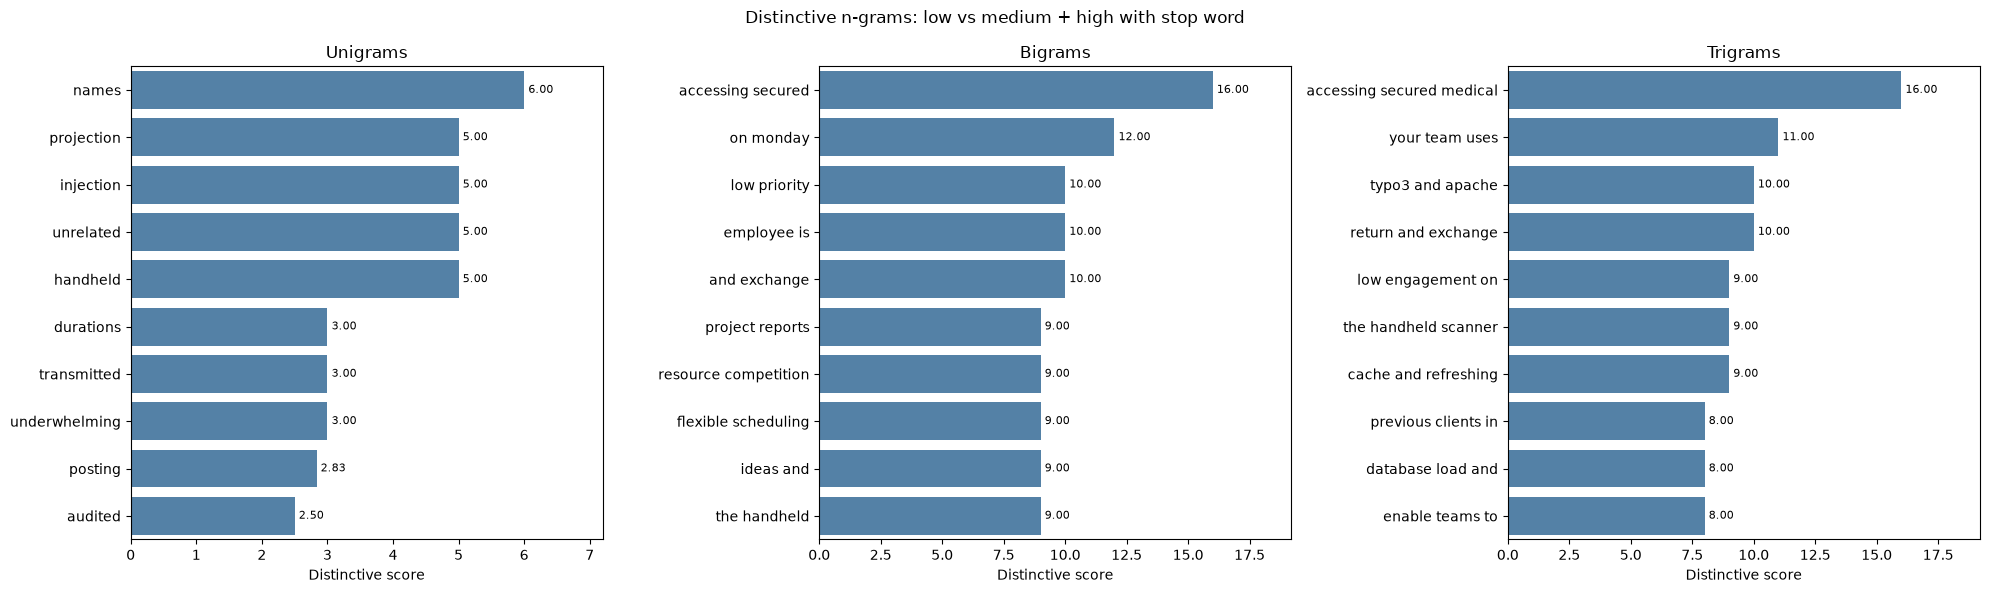

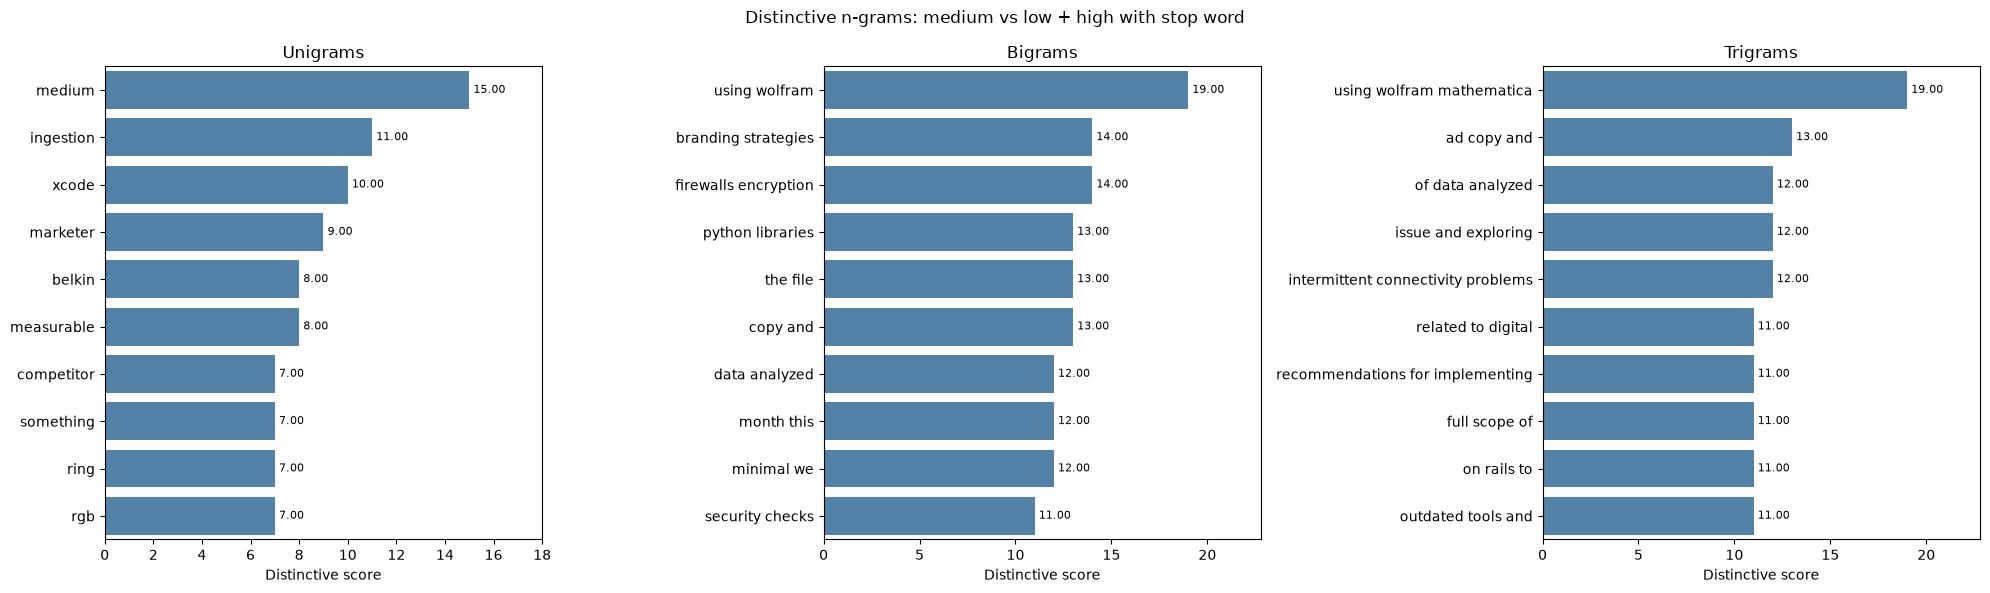

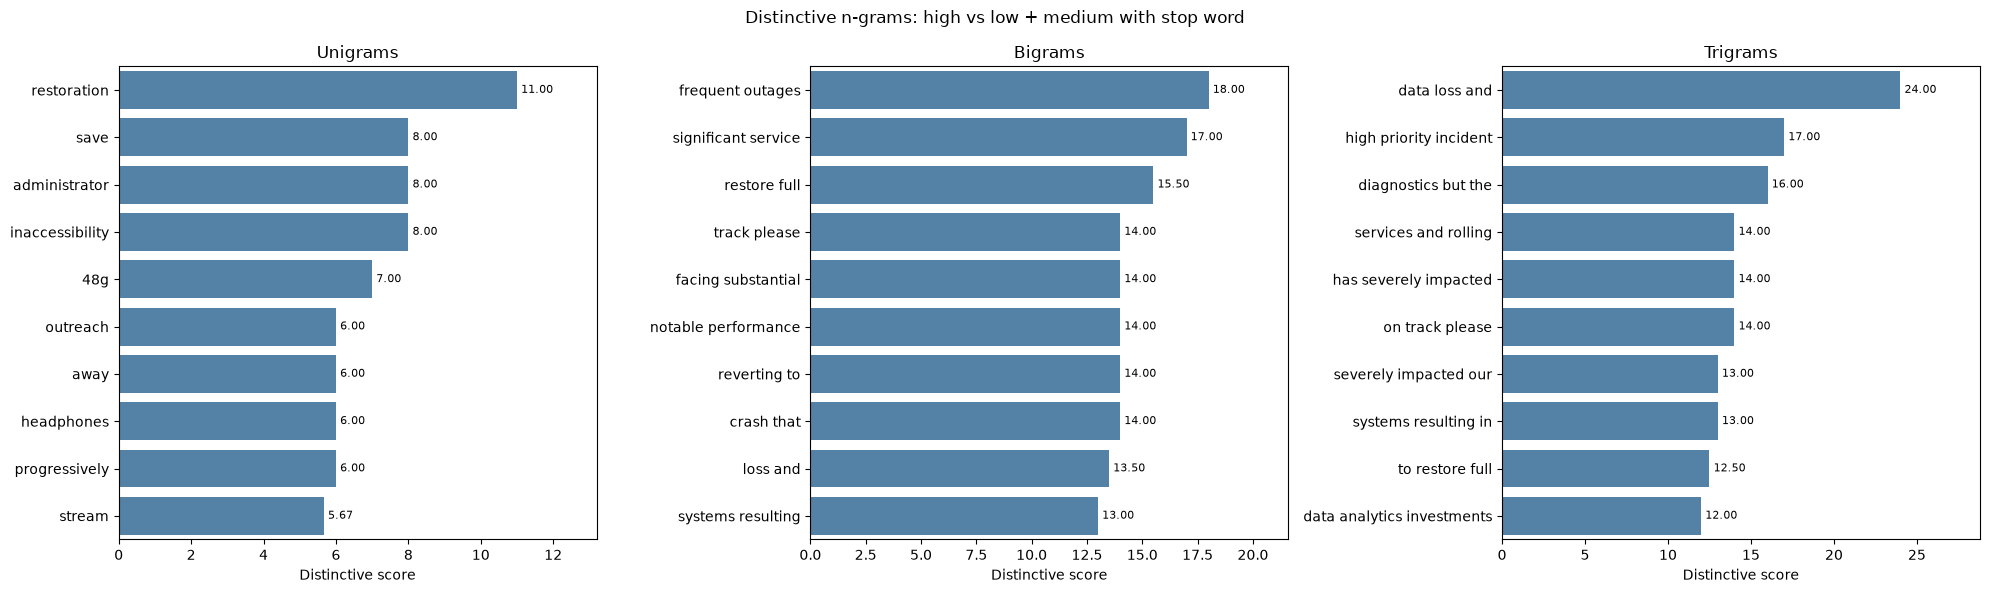

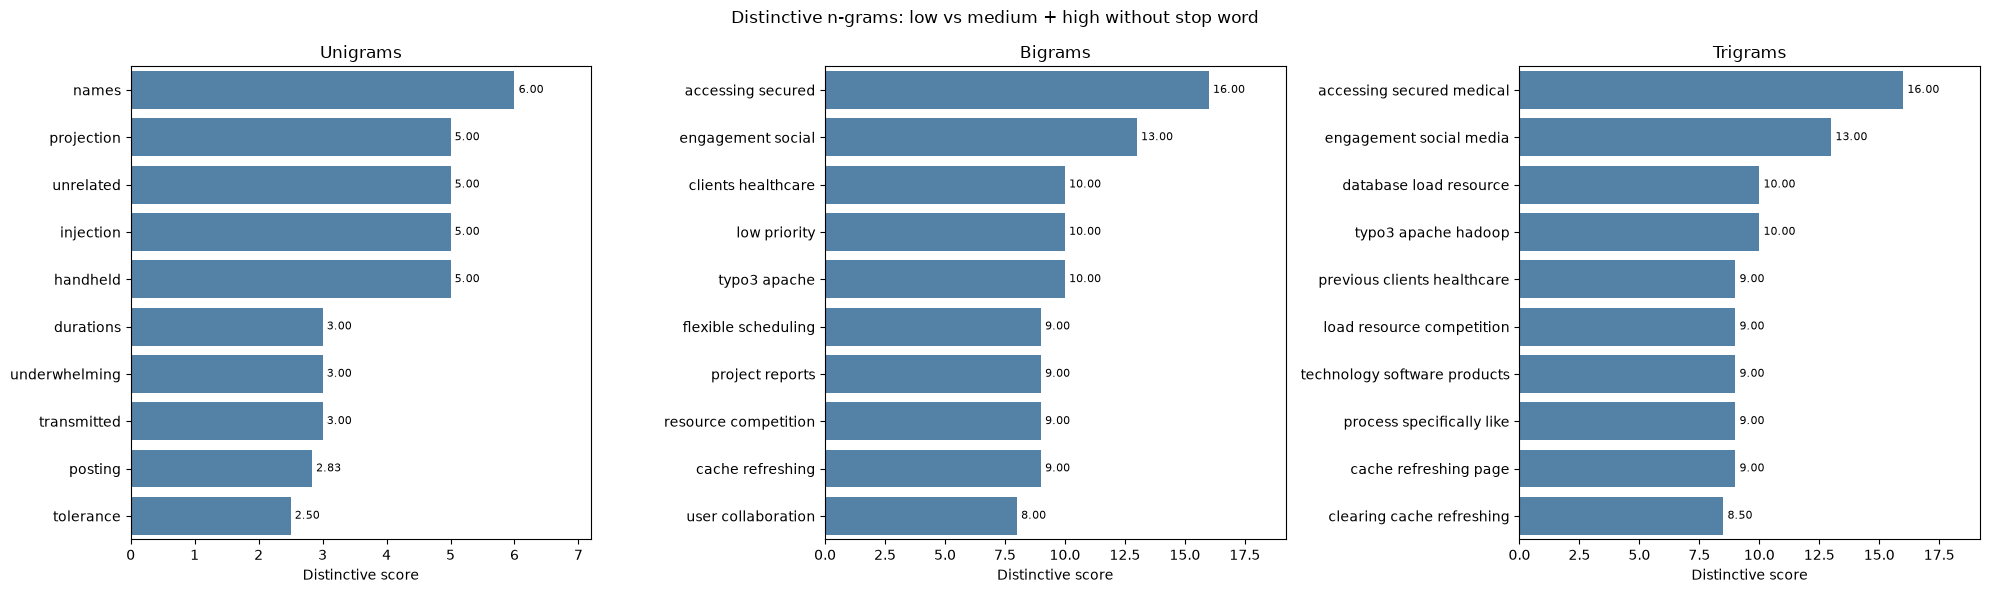

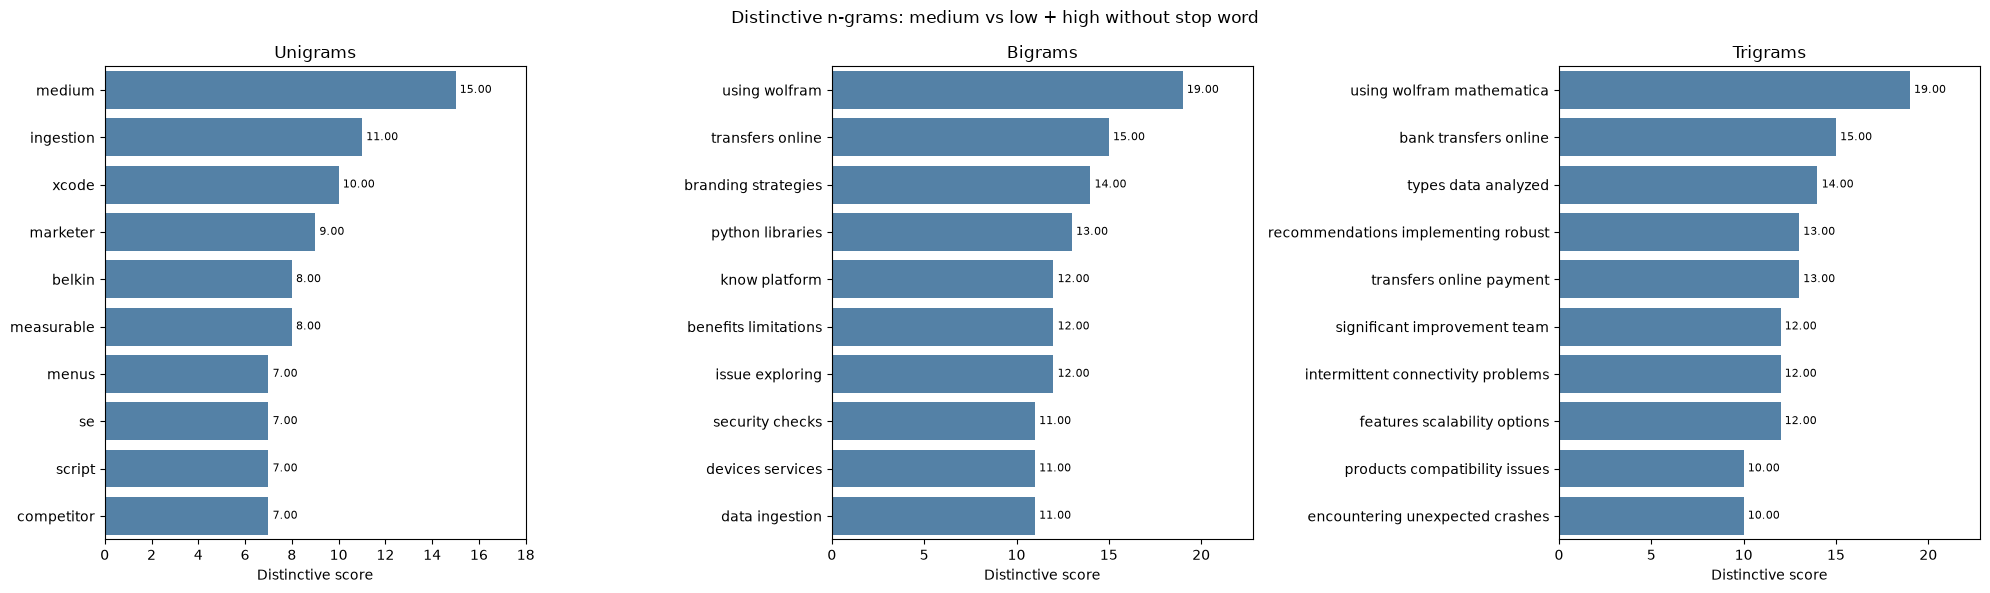

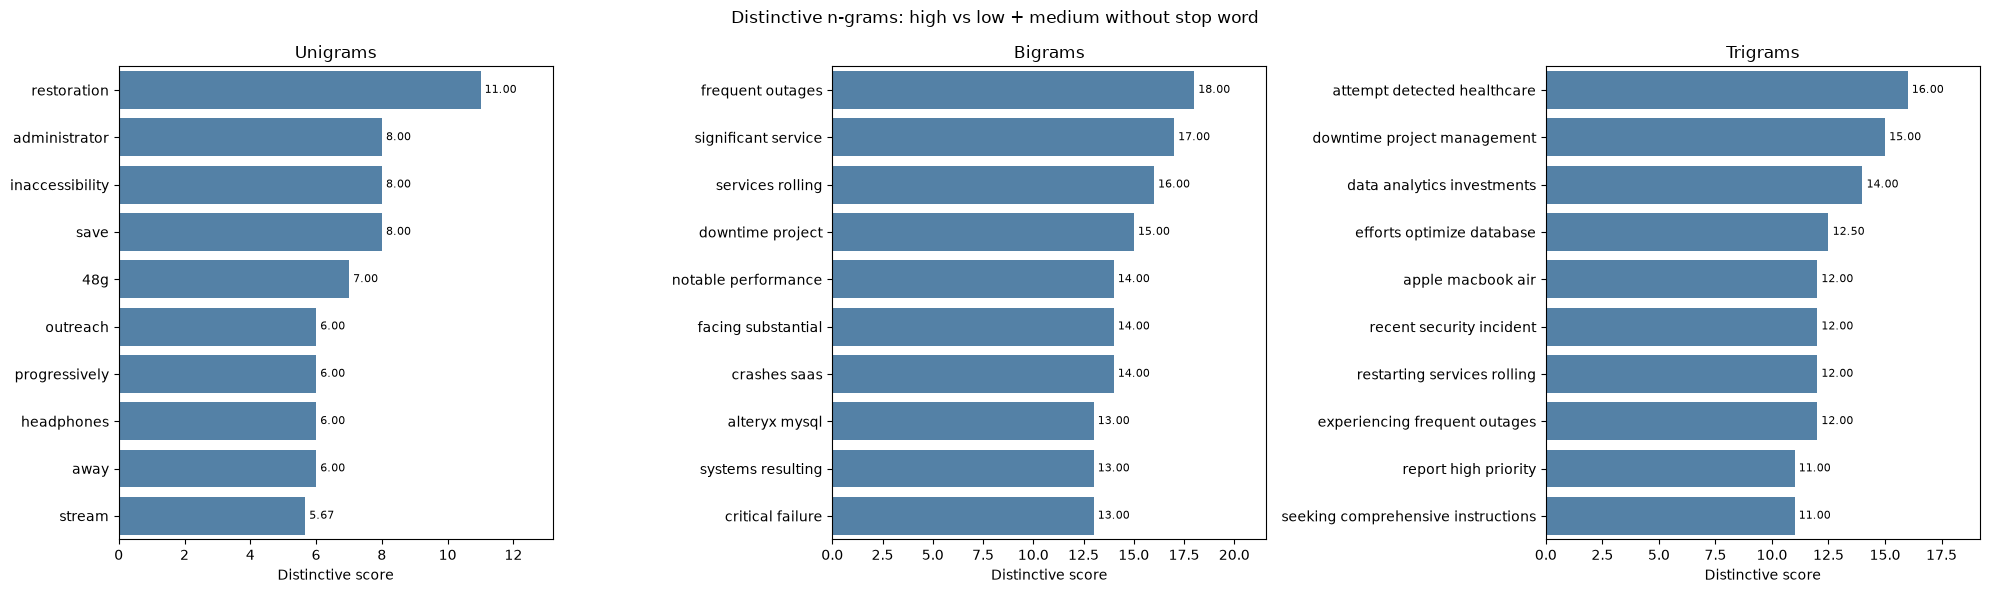

In [53]:
for priority in priorities:
    plot_distinctive(priority, distinctive_with_stop,with_stopword=True)
for priority in priorities:
    plot_distinctive(priority, distinctive_without_stop,with_stopword=False)

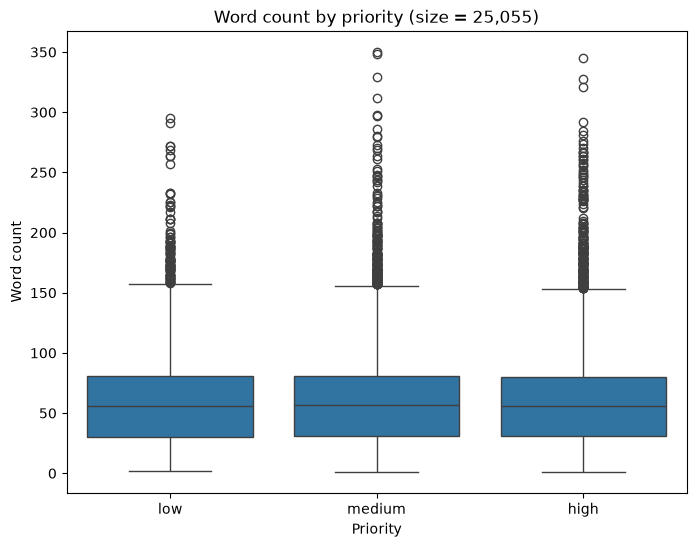

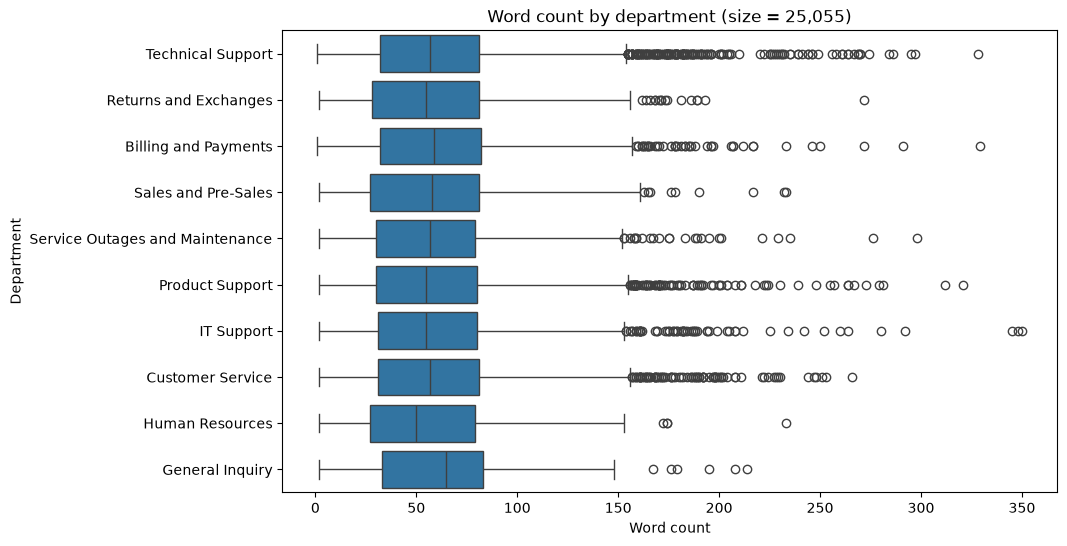

In [20]:
# FOR YOU AGENT
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Priority",
    y="word_count",
    order=["low", "medium", "high"]
)
plt.title(f"Word count by priority (size = {len(df):,})")
plt.xlabel("Priority")
plt.ylabel("Word count")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="word_count",
    y="Department"
)
plt.title(f"Word count by department (size = {len(df):,})")
plt.xlabel("Word count")
plt.ylabel("Department")
plt.show()


### 5. visualize bivariate relation

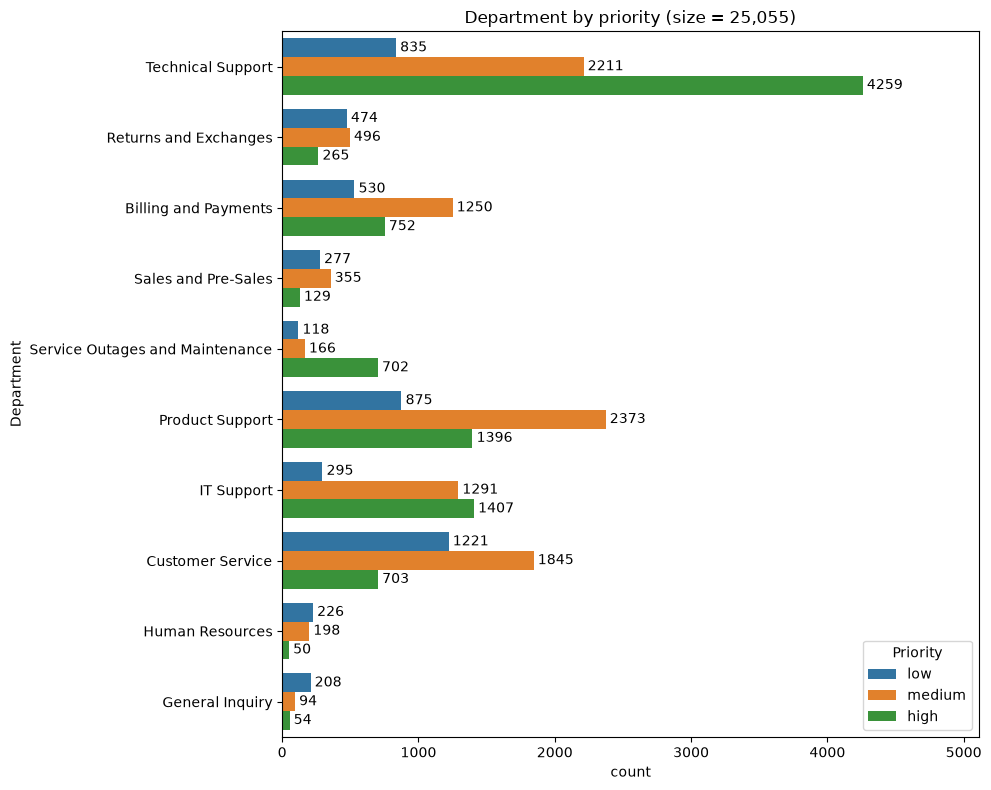

In [22]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(data=df, y="Department", hue="Priority", hue_order=["low", "medium", "high"])
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.0f", padding=3)
ax.margins(x=0.2)
plt.title(f"Department by priority (size = {len(df):,})")
plt.tight_layout()
plt.show()


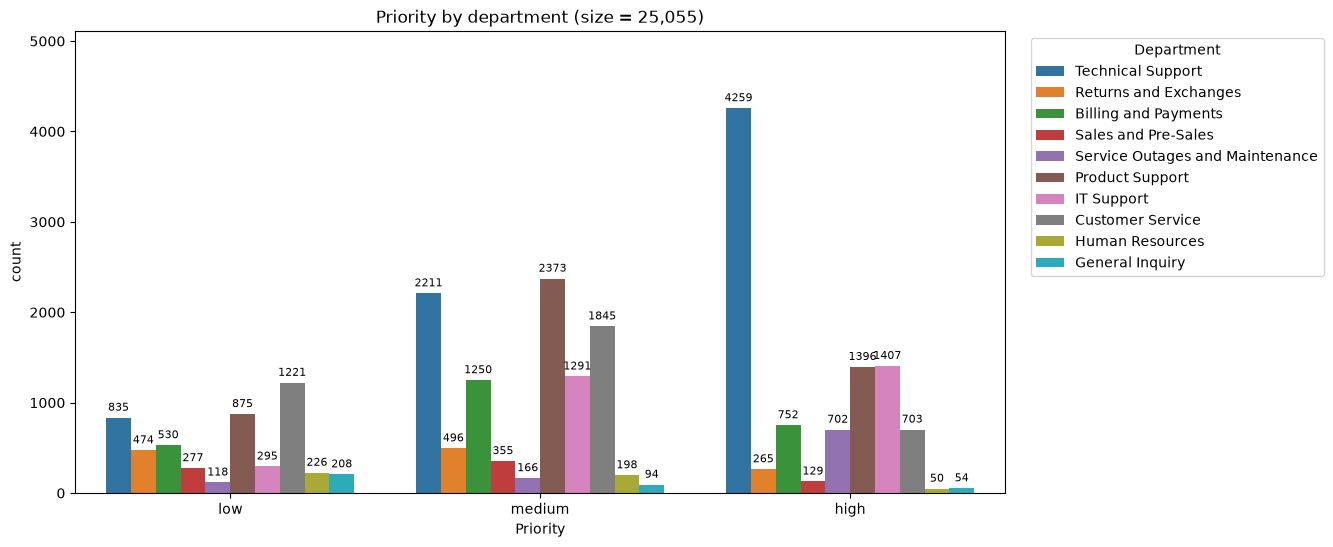

In [23]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="Priority", hue="Department", order=["low", "medium", "high"])
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)
ax.set(title=f"Priority by department (size = {len(df):,})")
ax.margins(y=0.2)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Department")
plt.show()


In [24]:


department_priority_pct = pd.crosstab(
    df["Department"],
    df["Priority"],
    normalize="index"
).mul(100).round(2)

department_priority_pct


Priority,high,low,medium
Department,,,
Billing and Payments,29.70,20.93,49.37
Customer Service,18.65,32.40,48.95
General Inquiry,15.17,58.43,26.40
Human Resources,10.55,47.68,41.77
IT Support,47.01,9.86,43.13
Product Support,30.06,18.84,51.10
Returns and Exchanges,21.46,38.38,40.16
Sales and Pre-Sales,16.95,36.40,46.65
Service Outages and Maintenance,71.20,11.97,16.84
